#### Get Predictions

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
# Load test Set
x_test_set = pd.read_csv("./x_test_set.csv")
y_test_set = pd.read_csv("./y_test_set.csv")

In [4]:
!ls

drive  sample_data  x_test_set.csv  y_test_set.csv


In [5]:
# Load The Model
model = joblib.load("./drive/MyDrive/git_projects/my_model.pkl")
model

RandomForestRegressor(oob_score=True)

In [6]:
# Prediction
y_pred = model.predict(x_test_set)
y_pred

array([188750.73 , 177517.65 , 169483.845, ..., 267582.4  , 254995.93 ,
       363306.625])

In [7]:
# Get Test Dataset Frame
y_test_df = pd.DataFrame(y_test_set, columns=["salary"])
y_test_df.reset_index(inplace=True)
y_test_df = y_test_df.drop("index", axis=1)
y_test_df.head(3)

,salary
0,176284.0
1,157717.0
2,186763.0


In [8]:
# Get Predction DataSet Frame
y_pred_df = pd.DataFrame(y_pred, columns=["salary_pred"])
y_pred_df.head(3)

,salary_pred
0,188750.730
1,177517.650
2,169483.845


In [9]:
# Combine The Two DataSet
y_pred_real_df = pd.concat([y_pred_df, y_test_df], axis=1)
y_pred_real_df.head(3)

,salary_pred,salary
0,188750.730,176284.0
1,177517.650,157717.0
2,169483.845,186763.0


#### Model Improvements

In [10]:
'''
    - Result Regression Visualisation
    - MAE (Mean Absolute Error) → average difference
    - RMSE (Root Mean Squared Error) → penalizes big errors
    - Residuals
    - R² → % of variance explained by model
    - Feature Importance: mesure how much each feature combined to the model
    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV
'''
# PROBLEM: HOW I CAN DEAL WITH NORMALIZED DATA

# Visualtion Of MEA, RMSE, ...
# How we can use This MEA, .. to improve the model
# Improve Model Performance

'\n    - Result Regression Visualisation\n    - MAE (Mean Absolute Error) → average difference\n    - RMSE (Root Mean Squared Error) → penalizes big errors\n    - Residuals\n    - R² → % of variance explained by model\n    - Feature Importance: mesure how much each feature combined to the model\n    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV\n'

In [11]:
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r_2
from math import sqrt
import matplotlib.pyplot as plt

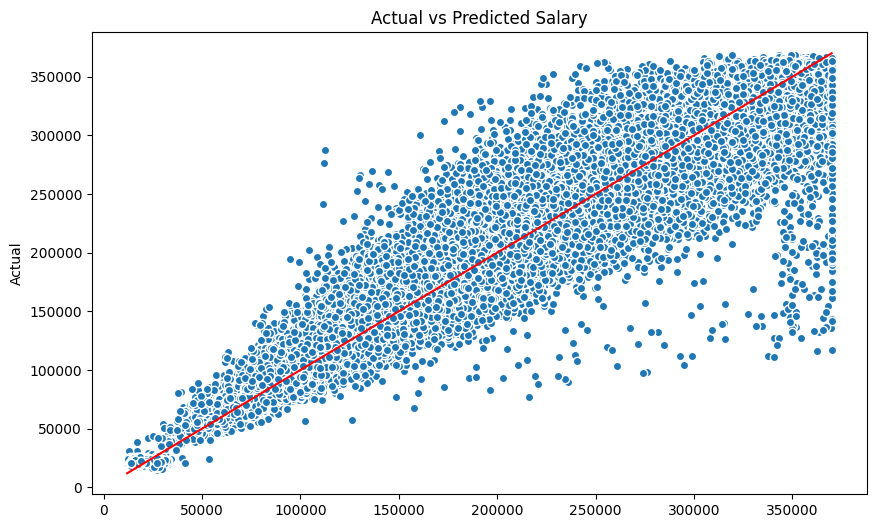

In [12]:
# Visualizing The Regression Results: Predicted vs Actual Visualtion
# FROM: https://codesignal.com/learn/courses/regression-analysis-to-model-diamond-prices/lessons/visualizing-actual-vs-predicted-prices-in-regression-models

plt.figure(figsize=(10, 6))

# Add Scatter For Visuale The Points
plt.scatter(y_pred_real_df["salary"], y_pred_real_df["salary_pred"], edgecolors="w")
plt.ylabel("Prediction")
plt.ylabel("Actual")
plt.title('Actual vs Predicted Salary')

# Visuale The Line For The Prefect Prediction
limits = [y_pred_real_df["salary"].min(), y_pred_real_df["salary"].max()]
plt.plot(limits, limits, color="red", linestyle="-", ) # draw line with coordinate (x1, y1) and (x2, y2)

In [13]:
# Get Mean Absolute Error (MAE)
mae_val = sum(abs(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"])) / y_pred_real_df["salary"].size
print(mae_val)
mae(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

22907.01938197619


22907.01938197619

In [14]:
# Root Mean Squared Error (RMSE)
len = y_pred_real_df["salary_pred"].count()
rmse_val = sqrt(sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / len)
print(rmse_val)
rmse(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

32048.177556673665


32048.177556673665

In [15]:
# Get R²
mean_y_test_set = y_pred_real_df["salary_pred"].mean()
r_2_val = 1 - (sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / sum(pow(y_pred_real_df["salary"] - mean_y_test_set, 2)))
print(r_2_val)

r_2(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

0.8606356460346503


0.8606356370041295

In [16]:
# Get Adjustement R²


In [17]:
# Features Importance
features_names = list(model.feature_names_in_)
features_importances = list(model.feature_importances_)
dic_f = {}
for i in range(len(features_names)):
    dic_f[features_names[i]] = features_importances[i]
print(dic_f)

# Visuale The Feature Importance
plt.figure(figsize=(12, 14))
plt.barh(features_names, features_importances)

TypeError: 'numpy.int64' object is not callable